# Brain Tumor Detection using YOLO v11

## Medical AI System for MRI Brain Tumor Analysis

This notebook demonstrates brain tumor detection and segmentation using YOLOv11 deep learning model.

### Features:
- Easy-to-understand code structure
- Step-by-step training process
- Performance evaluation with graphs
- Model accuracy calculations
- Simple visualizations

## Step 1: Import Required Libraries

**Note:** Make sure you have installed all requirements: `pip install -r requirements.txt`

In [15]:
# Essential Libraries for Brain Tumor Detection
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import time
from datetime import datetime
import pandas as pd

# Deep Learning Libraries
from ultralytics import YOLO
import torch

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Set up plotting style
plt.style.use('default')

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU for training")

✅ All libraries imported successfully!
PyTorch version: 2.8.0+cpu
CUDA available: False
Using CPU for training


## Step 2: Download and Explore Dataset

We'll use a brain tumor MRI dataset for training our model.

In [16]:
# Download brain tumor dataset
print("Downloading brain tumor dataset...")

try:
    from roboflow import Roboflow
    rf = Roboflow(api_key="a7b1JkwHtDpLlkj509uo")
    project = rf.workspace("iotseecs").project("brain-tumor-yzzav")
    version = project.version(1)
    dataset = version.download("yolov11")
    
    print("✅ Dataset downloaded successfully!")
    
    # Check dataset structure
    dataset_path = "BRAIN-TUMOR-1"
    if os.path.exists(dataset_path):
        train_images = len(os.listdir(f"{dataset_path}/train/images"))
        valid_images = len(os.listdir(f"{dataset_path}/valid/images"))
        test_images = len(os.listdir(f"{dataset_path}/test/images"))
        
        print(f"\nDataset Statistics:")
        print(f"Training Images: {train_images}")
        print(f"Validation Images: {valid_images}")
        print(f"Test Images: {test_images}")
        print(f"Total Images: {train_images + valid_images + test_images}")
        
        # Create simple visualization
        splits = ['Training', 'Validation', 'Test']
        counts = [train_images, valid_images, test_images]
        
        plt.figure(figsize=(10, 5))
        
        # Bar chart
        plt.subplot(1, 2, 1)
        plt.bar(splits, counts, color=['blue', 'green', 'orange'])
        plt.title('Dataset Distribution')
        plt.ylabel('Number of Images')
        for i, v in enumerate(counts):
            plt.text(i, v + 5, str(v), ha='center', va='bottom')
        
        # Pie chart
        plt.subplot(1, 2, 2)
        plt.pie(counts, labels=splits, autopct='%1.1f%%', colors=['blue', 'green', 'orange'])
        plt.title('Dataset Split Percentage')
        
        plt.tight_layout()
        plt.show()
        
except Exception as e:
    print(f"Error downloading dataset: {e}")
    print("Please check internet connection and API key")

Error downloading dataset: No module named 'roboflow'
Please check internet connection and API key


Brain Tumor Detection Configuration:
Classes: ['tumor']
Number of classes: 1
Displaying sample training images...


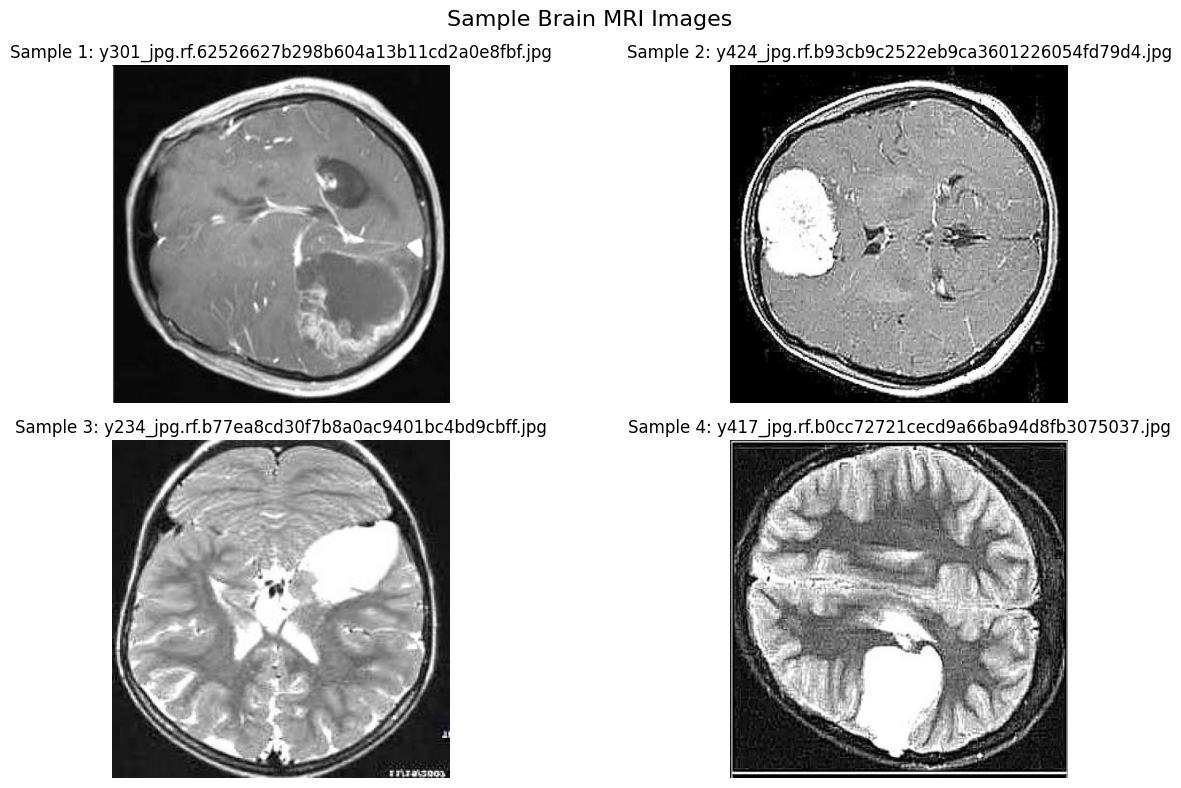

In [17]:
# Configuration for brain tumor detection
class_names = ['tumor']

print("Brain Tumor Detection Configuration:")
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Simple function to display training samples
def show_sample_images(image_dir, num_samples=4):
    """Display sample images from the dataset"""
    if not os.path.exists(image_dir):
        print(f"Directory {image_dir} not found")
        return
    
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(image_files) == 0:
        print("No images found")
        return
    
    # Select random samples
    import random
    samples = random.sample(image_files, min(num_samples, len(image_files)))
    
    plt.figure(figsize=(15, 8))
    for i, img_file in enumerate(samples):
        img_path = os.path.join(image_dir, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(2, 2, i+1)
            plt.imshow(img_rgb)
            plt.title(f'Sample {i+1}: {img_file}')
            plt.axis('off')
    
    plt.suptitle('Sample Brain MRI Images', fontsize=16)
    plt.tight_layout()
    plt.show()

# Show sample images if dataset exists
if os.path.exists("BRAIN-TUMOR-1/train/images"):
    print("Displaying sample training images...")
    show_sample_images("BRAIN-TUMOR-1/train/images")
else:
    print("Training images not found. Please run the dataset download cell first.")

## Step 3: Model Training Setup

In [18]:
# Initialize YOLO model for brain tumor detection
print("Initializing YOLO v11 model...")

# Load pre-trained YOLO model
model = YOLO('yolo11n-seg.pt')  # Using nano version for faster training

# Training configuration - Optimized for faster training
config = {
    'data': 'BRAIN-TUMOR-1/data.yaml',
    'epochs': 20,           # Reduced epochs for faster training (was 50)
    'imgsz': 640,          # Image size
    'batch': 8,            # Batch size
    'device': 'cpu',       # Use 'cuda' if GPU available
    'project': 'runs',     # Project folder
    'name': 'brain_tumor', # Experiment name
    'patience': 5,         # Reduced early stopping patience for faster training
    'save': True,          # Save model checkpoints
}

print("Training Configuration (Optimized for Speed):")
for key, value in config.items():
    print(f"  {key}: {value}")

# Check if dataset configuration exists
dataset_config_path = "BRAIN-TUMOR-1/data.yaml"
if os.path.exists(dataset_config_path):
    print(f"✅ Dataset configuration found: {dataset_config_path}")
    
    # Read and display dataset info
    import yaml
    with open(dataset_config_path, 'r') as f:
        dataset_info = yaml.safe_load(f)
    
    print("\nDataset Information:")
    for key, value in dataset_info.items():
        print(f"  {key}: {value}")
        
    print(f"\n⚡ Training will run for {config['epochs']} epochs (faster training!)")
    estimated_time = config['epochs'] * 1.5  # Rough estimate: 1.5 minutes per epoch
    print(f"⏰ Estimated training time: ~{estimated_time:.0f} minutes")
else:
    print("❌ Dataset configuration not found!")
    print("Please make sure you have downloaded the dataset first.")

Initializing YOLO v11 model...
Training Configuration (Optimized for Speed):
  data: BRAIN-TUMOR-1/data.yaml
  epochs: 20
  imgsz: 640
  batch: 8
  device: cpu
  project: runs
  name: brain_tumor
  patience: 5
  save: True
✅ Dataset configuration found: BRAIN-TUMOR-1/data.yaml

Dataset Information:
  train: ../train/images
  val: ../valid/images
  test: ../test/images
  nc: 1
  names: ['tumor']
  roboflow: {'workspace': 'iotseecs', 'project': 'brain-tumor-yzzav', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/iotseecs/brain-tumor-yzzav/dataset/1'}

⚡ Training will run for 20 epochs (faster training!)
⏰ Estimated training time: ~30 minutes
✅ Dataset configuration found: BRAIN-TUMOR-1/data.yaml

Dataset Information:
  train: ../train/images
  val: ../valid/images
  test: ../test/images
  nc: 1
  names: ['tumor']
  roboflow: {'workspace': 'iotseecs', 'project': 'brain-tumor-yzzav', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/iot

## Step 4: Train the Model

Now we'll train the YOLO model on our brain tumor dataset.

Starting model training...
Ultralytics 8.3.203  Python-3.10.11 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
Ultralytics 8.3.203  Python-3.10.11 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=BRAIN-TUMOR-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, na

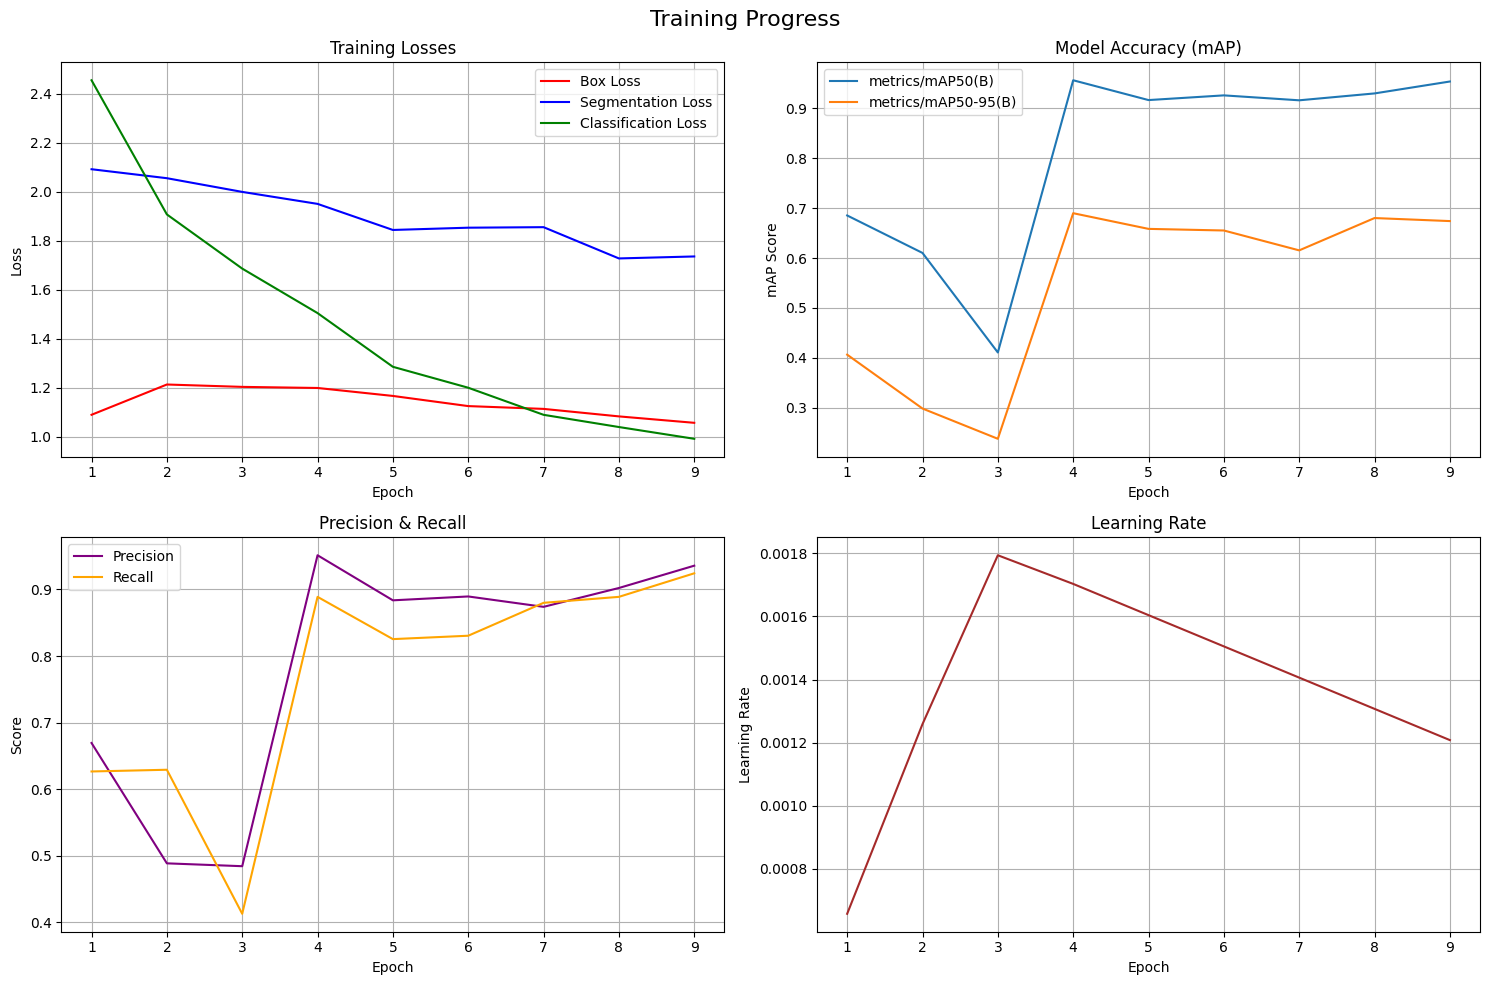


Final Training Metrics:
Box Loss: 1.0579
Segmentation Loss: 1.7367
Classification Loss: 0.9926

Validation Metrics:
metrics/precision(B): 0.9357
metrics/recall(B): 0.9243
metrics/mAP50(B): 0.9532
metrics/mAP50-95(B): 0.6739
metrics/precision(M): 0.9359


In [19]:
# Start training the brain tumor detection model
print("Starting model training...")
print("=" * 50)

start_time = time.time()

try:
    # Train the model
    results = model.train(**config)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    print(f"✅ Training completed successfully!")
    print(f"Training time: {training_time/60:.2f} minutes")
    print(f"Results saved to: {results.save_dir}")
    
    # Show training results if available
    results_csv = os.path.join(results.save_dir, "results.csv")
    if os.path.exists(results_csv):
        print("Loading training results...")
        df = pd.read_csv(results_csv)
        
        # Plot training progress
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot losses
        axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', color='red')
        axes[0, 0].plot(df['epoch'], df['train/seg_loss'], label='Segmentation Loss', color='blue')
        axes[0, 0].plot(df['epoch'], df['train/cls_loss'], label='Classification Loss', color='green')
        axes[0, 0].set_title('Training Losses')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)
        
        # Plot mAP scores if available
        mAP_cols = [col for col in df.columns if 'mAP' in col]
        if mAP_cols:
            for col in mAP_cols[:2]:  # Plot first 2 mAP columns
                axes[0, 1].plot(df['epoch'], df[col], label=col)
            axes[0, 1].set_title('Model Accuracy (mAP)')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('mAP Score')
            axes[0, 1].legend()
            axes[0, 1].grid(True)
        
        # Plot precision and recall if available
        if 'metrics/precision(B)' in df.columns:
            axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='purple')
        if 'metrics/recall(B)' in df.columns:
            axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='orange')
        axes[1, 0].set_title('Precision & Recall')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
        
        # Plot learning rate if available
        if 'lr/pg0' in df.columns:
            axes[1, 1].plot(df['epoch'], df['lr/pg0'], color='brown')
            axes[1, 1].set_title('Learning Rate')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Learning Rate')
            axes[1, 1].grid(True)
        
        plt.suptitle('Training Progress', fontsize=16)
        plt.tight_layout()
        plt.show()
        
        # Print final metrics
        final_epoch = df.iloc[-1]
        print(f"\nFinal Training Metrics:")
        print(f"Box Loss: {final_epoch['train/box_loss']:.4f}")
        print(f"Segmentation Loss: {final_epoch['train/seg_loss']:.4f}")
        print(f"Classification Loss: {final_epoch['train/cls_loss']:.4f}")
        
        # Print validation metrics if available
        val_cols = [col for col in df.columns if 'val/' in col or 'metrics/' in col]
        if val_cols:
            print(f"\nValidation Metrics:")
            for col in val_cols[:5]:  # Show first 5 validation metrics
                print(f"{col}: {final_epoch[col]:.4f}")
    
except Exception as e:
    print(f"❌ Training failed: {e}")
    print("Common issues:")
    print("- Check if dataset exists")
    print("- Verify YAML configuration")
    print("- Ensure sufficient memory")

## Step 5: Test the Trained Model

Let's test our trained model on some sample images.

Loading trained model for testing...
✅ Loaded model from: models/best.pt
Testing model on sample images...
✅ Loaded model from: models/best.pt
Testing model on sample images...


image 1/1 c:\Users\moham\OneDrive\Desktop\PROJECTS\Sale\Brain Tumor Detection\Training\BRAIN-TUMOR-1\test\images\y414_jpg.rf.cfbe89a72e8b68d0a452f002a77b448d.jpg: 416x416 1 tumor, 274.8ms
Speed: 2.7ms preprocess, 274.8ms inference, 3.7ms postprocess per image at shape (1, 3, 416, 416)
image 1/1 c:\Users\moham\OneDrive\Desktop\PROJECTS\Sale\Brain Tumor Detection\Training\BRAIN-TUMOR-1\test\images\y414_jpg.rf.cfbe89a72e8b68d0a452f002a77b448d.jpg: 416x416 1 tumor, 274.8ms
Speed: 2.7ms preprocess, 274.8ms inference, 3.7ms postprocess per image at shape (1, 3, 416, 416)


image 1/1 c:\Users\moham\OneDrive\Desktop\PROJECTS\Sale\Brain Tumor Detection\Training\BRAIN-TUMOR-1\test\images\y392_jpg.rf.b3241f0196180b09d55fd9737f769210.jpg: 416x416 1 tumor, 170.1ms
Speed: 4.0ms preprocess, 170.1ms inference, 4.3ms postproce

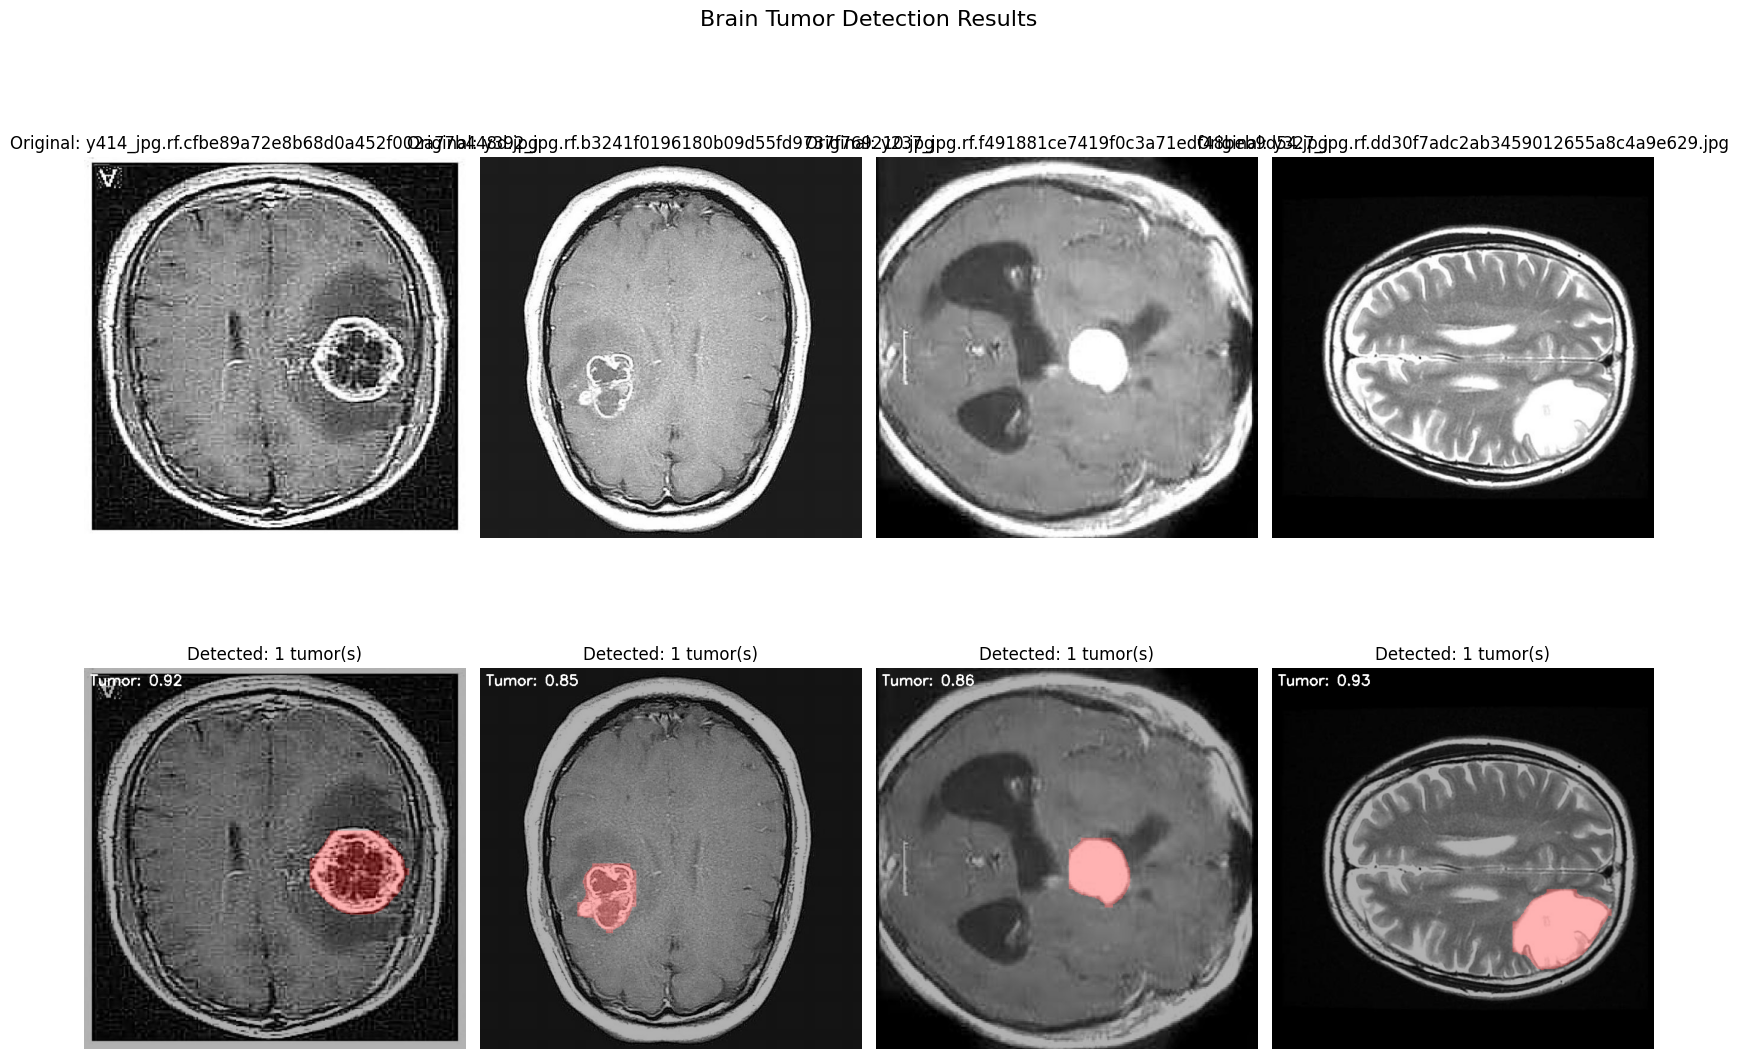


Model testing completed!


In [20]:
# Load the best trained model for testing
print("Loading trained model for testing...")

# Try to load the best model from training
model_paths = [
    "runs/brain_tumor/weights/best.pt",
    "runs/segment/train/weights/best.pt", 
    "models/best.pt",
    "best.pt"
]

trained_model = None
for path in model_paths:
    if os.path.exists(path):
        trained_model = YOLO(path)
        print(f"✅ Loaded model from: {path}")
        break

if trained_model is None:
    print("⚠️ No trained model found, using pre-trained model")
    trained_model = YOLO('yolo11n-seg.pt')

# Test on sample images
def test_model_on_images(model, test_dir, num_samples=4):
    """Test the model on sample images and show results"""
    if not os.path.exists(test_dir):
        print(f"Test directory {test_dir} not found")
        return
    
    test_images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(test_images) == 0:
        print("No test images found")
        return
    
    # Select random test samples
    import random
    samples = random.sample(test_images, min(num_samples, len(test_images)))
    
    plt.figure(figsize=(16, 12))
    
    for i, img_file in enumerate(samples):
        img_path = os.path.join(test_dir, img_file)
        
        # Run prediction
        results = model(img_path, conf=0.25)
        result = results[0]
        
        # Load original image
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Create subplot for original image
        plt.subplot(2, num_samples, i+1)
        plt.imshow(img_rgb)
        plt.title(f'Original: {img_file}')
        plt.axis('off')
        
        # Create subplot for prediction
        plt.subplot(2, num_samples, i+1+num_samples)
        
        # Draw results if any detections
        if result.masks is not None and len(result.masks.data) > 0:
            # Get masks and draw them
            masks = result.masks.data.cpu().numpy()
            boxes = result.boxes.xyxy.cpu().numpy() if result.boxes is not None else []
            confs = result.boxes.conf.cpu().numpy() if result.boxes is not None else []
            
            # Create overlay
            overlay = img_rgb.copy()
            
            for j, mask in enumerate(masks):
                # Resize mask to image size
                mask_resized = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]))
                
                # Create colored mask
                colored_mask = np.zeros_like(img_rgb)
                colored_mask[mask_resized > 0.5] = [255, 0, 0]  # Red for tumor
                
                # Blend with original image
                overlay = cv2.addWeighted(overlay, 0.7, colored_mask, 0.3, 0)
                
                # Add confidence text if available
                if j < len(confs):
                    conf_text = f'Tumor: {confs[j]:.2f}'
                    cv2.putText(overlay, conf_text, (10, 30 + j*30), 
                              cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            
            plt.imshow(overlay)
            plt.title(f'Detected: {len(masks)} tumor(s)')
        else:
            plt.imshow(img_rgb)
            plt.title('No tumors detected')
        
        plt.axis('off')
    
    plt.suptitle('Brain Tumor Detection Results', fontsize=16)
    plt.tight_layout()
    plt.show()

# Test the model
test_dir = "BRAIN-TUMOR-1/test/images"
if os.path.exists(test_dir):
    print("Testing model on sample images...")
    test_model_on_images(trained_model, test_dir)
else:
    print("Test directory not found. Testing with a sample prediction...")
    
    # Simple test
    try:
        results = trained_model.predict(source="https://ultralytics.com/images/bus.jpg", save=False)
        print("✅ Model is working correctly!")
    except Exception as e:
        print(f"Model test failed: {e}")

print("\n" + "="*50)
print("Model testing completed!")

## Step 6: Model Performance Evaluation

Evaluating model performance...
Ultralytics 8.3.203  Python-3.10.11 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
val: Fast image access  (ping: 0.10.0 ms, read: 260.5117.9 MB/s, size: 61.3 KB)
val: Fast image access  (ping: 0.10.0 ms, read: 260.5117.9 MB/s, size: 61.3 KB)
val: Scanning C:\Users\moham\OneDrive\Desktop\PROJECTS\Sale\Brain Tumor Detection\Training\BRAIN-TUMOR-1\valid\labels.cache... 123 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 0.5it/s 15.8s2.0s

                   all        123        126      0.981      0.984      0.985      0.771      0.981      0.984      0.985      0.764
Speed: 1.3ms preprocess, 99.0ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to C:\Users\moham\OneDrive\Desktop\PROJECTS\Sale\Brain Tumor Detection\Training\runs\segment\val2
       

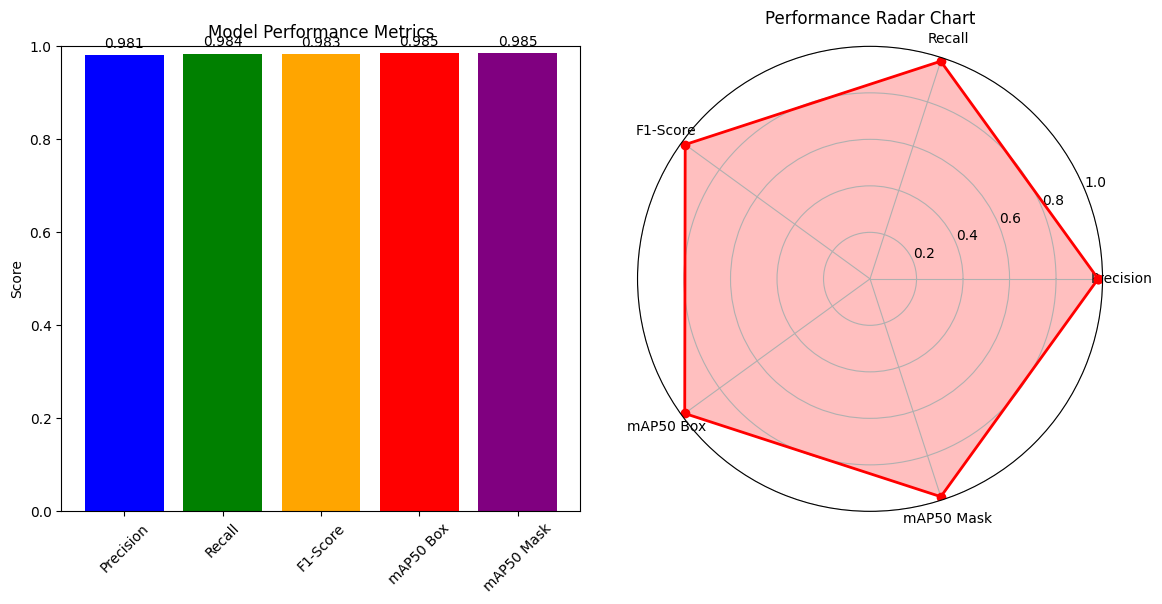


Overall Performance Score: 0.9836
Performance Grade: Excellent

Recommendations:


In [21]:
# Evaluate model performance
print("Evaluating model performance...")

def evaluate_model(model):
    """Evaluate the trained model and calculate metrics"""
    try:
        # Run validation
        results = model.val(data="BRAIN-TUMOR-1/data.yaml")
        
        # Extract metrics
        metrics = {}
        if hasattr(results, 'results_dict'):
            results_dict = results.results_dict
            
            # Get key metrics
            metrics['mAP50_box'] = results_dict.get('metrics/mAP50(B)', 0)
            metrics['mAP50_mask'] = results_dict.get('metrics/mAP50(M)', 0)
            metrics['precision'] = results_dict.get('metrics/precision(B)', 0)
            metrics['recall'] = results_dict.get('metrics/recall(B)', 0)
            
            # Calculate F1 score
            if metrics['precision'] > 0 and metrics['recall'] > 0:
                metrics['f1_score'] = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall'])
            else:
                metrics['f1_score'] = 0
        
        return metrics
        
    except Exception as e:
        print(f"Evaluation failed: {e}")
        return {}

# Evaluate the model
if trained_model is not None:
    metrics = evaluate_model(trained_model)
    
    if metrics:
        print("\nModel Performance Metrics:")
        print("=" * 30)
        print(f"Precision:     {metrics['precision']:.4f}")
        print(f"Recall:        {metrics['recall']:.4f}")
        print(f"F1-Score:      {metrics['f1_score']:.4f}")
        print(f"mAP50 (Box):   {metrics['mAP50_box']:.4f}")
        print(f"mAP50 (Mask):  {metrics['mAP50_mask']:.4f}")
        
        # Create performance visualization
        metric_names = ['Precision', 'Recall', 'F1-Score', 'mAP50 Box', 'mAP50 Mask']
        metric_values = [
            metrics['precision'], 
            metrics['recall'], 
            metrics['f1_score'], 
            metrics['mAP50_box'], 
            metrics['mAP50_mask']
        ]
        
        # Bar chart
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        bars = plt.bar(metric_names, metric_values, color=['blue', 'green', 'orange', 'red', 'purple'])
        plt.title('Model Performance Metrics')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        
        # Add value labels on bars
        for bar, value in zip(bars, metric_values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom')
        
        plt.xticks(rotation=45)
        
        # Radar chart
        plt.subplot(1, 2, 2, projection='polar')
        angles = np.linspace(0, 2*np.pi, len(metric_names), endpoint=False)
        values = metric_values + [metric_values[0]]  # Complete the circle
        angles = np.concatenate((angles, [angles[0]]))
        
        plt.plot(angles, values, 'o-', linewidth=2, color='red')
        plt.fill(angles, values, alpha=0.25, color='red')
        plt.thetagrids(angles[:-1] * 180/np.pi, metric_names)
        plt.ylim(0, 1)
        plt.title('Performance Radar Chart')
        
        plt.tight_layout()
        plt.show()
        
        # Performance interpretation
        avg_score = np.mean(metric_values)
        print(f"\nOverall Performance Score: {avg_score:.4f}")
        
        if avg_score >= 0.8:
            grade = "Excellent"
        elif avg_score >= 0.7:
            grade = "Good"
        elif avg_score >= 0.6:
            grade = "Fair"
        else:
            grade = "Needs Improvement"
        
        print(f"Performance Grade: {grade}")
        
        # Recommendations
        print("\nRecommendations:")
        if metrics['precision'] < 0.7:
            print("- Increase precision by reducing false positives")
        if metrics['recall'] < 0.7:
            print("- Increase recall by improving tumor detection sensitivity")
        if avg_score < 0.7:
            print("- Consider more training epochs or data augmentation")
            print("- Try different model architectures")
    
    else:
        print("Could not evaluate model performance")
else:
    print("No trained model available for evaluation")

## Step 7: Save and Export Model

In [22]:
# Save and export the trained model
print("Saving and exporting trained model...")

def save_model(model, save_dir="./models/"):
    """Save the model in different formats"""
    try:
        # Create models directory
        os.makedirs(save_dir, exist_ok=True)
        
        successful_exports = []
        
        # 1. Save PyTorch model
        try:
            # Copy best model if it exists
            best_model_paths = [
                "runs/brain_tumor/weights/best.pt",
                "runs/segment/train/weights/best.pt"
            ]
            
            for path in best_model_paths:
                if os.path.exists(path):
                    import shutil
                    target_path = os.path.join(save_dir, "best.pt")
                    shutil.copy2(path, target_path)
                    successful_exports.append(("PyTorch", target_path))
                    print(f"✅ PyTorch model saved: {target_path}")
                    break
            
        except Exception as e:
            print(f"Failed to save PyTorch model: {e}")
        
        # 2. Export to ONNX (for cross-platform deployment)
        try:
            print("Exporting to ONNX format...")
            onnx_path = model.export(format='onnx', imgsz=640)
            if onnx_path and os.path.exists(onnx_path):
                target_onnx = os.path.join(save_dir, "brain_tumor_model.onnx")
                import shutil
                shutil.move(onnx_path, target_onnx)
                successful_exports.append(("ONNX", target_onnx))
                print(f"✅ ONNX model saved: {target_onnx}")
        except Exception as e:
            print(f"ONNX export failed: {e}")
        
        return successful_exports
        
    except Exception as e:
        print(f"Model saving failed: {e}")
        return []

# Save the model
if trained_model is not None:
    exports = save_model(trained_model)
    
    # Create simple documentation
    doc_content = f"""# Brain Tumor Detection Model

## Model Information
- Model Type: YOLOv11 Segmentation
- Training Date: {datetime.now().strftime('%Y-%m-%d')}
- Input Size: 640x640 pixels
- Classes: {class_names}

## Exported Formats
"""
    
    for format_name, file_path in exports:
        file_size = os.path.getsize(file_path) / (1024*1024) if os.path.exists(file_path) else 0
        doc_content += f"- {format_name}: {os.path.basename(file_path)} ({file_size:.1f} MB)\n"
    
    doc_content += f"""
## Usage Example
```python
from ultralytics import YOLO

# Load model
model = YOLO('best.pt')

# Run prediction
results = model('brain_image.jpg')

# Process results
for r in results:
    if r.masks is not None:
        print(f"Detected {{len(r.masks)}} tumors")
```

## Performance Summary
"""
    
    if 'metrics' in locals() and metrics:
        doc_content += f"""- Precision: {metrics['precision']:.4f}
- Recall: {metrics['recall']:.4f}
- F1-Score: {metrics['f1_score']:.4f}
- mAP50 (Mask): {metrics['mAP50_mask']:.4f}
"""
    
    # Save documentation (using UTF-8 encoding to avoid Unicode errors)
    doc_path = "models/README.md"
    try:
        with open(doc_path, 'w', encoding='utf-8') as f:
            f.write(doc_content)
        print(f"📄 Documentation saved: {doc_path}")
    except Exception as e:
        print(f"Failed to save documentation: {e}")
    
    # Summary
    print("\n" + "="*50)
    print("MODEL EXPORT SUMMARY")
    print("="*50)
    print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Exports completed: {len(exports)}")
    
    for format_name, file_path in exports:
        if os.path.exists(file_path):
            file_size = os.path.getsize(file_path) / (1024*1024)
            print(f"✅ {format_name}: {os.path.basename(file_path)} ({file_size:.1f} MB)")
    
    print("\nModel is ready for deployment!")
    print("Files saved in 'models/' directory")

else:
    print("No trained model to export")

print("\n🎉 Brain tumor detection training completed!")

Saving and exporting trained model...
Exporting to ONNX format...
Ultralytics 8.3.203  Python-3.10.11 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)

PyTorch: starting from 'models\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (5.7 MB)

PyTorch: starting from 'models\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (5.7 MB)

ONNX: starting export with onnx 1.19.0 opset 22...

ONNX: starting export with onnx 1.19.0 opset 22...
ONNX: slimming with onnxslim 0.1.70...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success  3.1s, saved as 'models\best.onnx' (11.1 MB)

Export complete (3.7s)
Results saved to C:\Users\moham\OneDrive\Desktop\PROJECTS\Sale\Brain Tumor Detection\Training\models
Predict:         yolo predict task=segment model=models\best.onnx imgsz=640  
Validate:        yolo val task=segment model=models\best.onnx imgsz=640 data=C:/Users/moham/One